In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.stats import weibull_min, norm
from scipy.integrate import quad
from scipy.optimize import minimize_scalar, curve_fit

warnings.filterwarnings("ignore")

In [4]:
# df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'lmp', 'user_load_zonal'])
# df.rename({'speed_HRRR': 'speed', 'ercot_power': 'power'}, axis=1, inplace=True)

df = pd.read_csv('../../data/processed/dataset_14-23.csv')
# normalize power and speed
df['npower'] = df['power'] / df['power'].max()
df['nspeed'] = (df['speed'] - df['speed'].min()) / (df['speed'].max() - df['speed'].min())

t = 64780 # split index
df_train = df[:t].copy() # train
df_test = df[t:].reset_index(drop=True).copy() # test

In [4]:
df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)

In [2]:
df = pd.read_csv('wevalidate_data/EIA_930.csv')
pluswind = pd.read_csv('wevalidate_data/pluswind-HRRR.csv')[['time_stamp', 'npower']]
pluswind['time_stamp'] = pd.to_datetime(pluswind['time_stamp']).astype(str)
pluswind.rename(columns={'time_stamp': 'datetime', 'npower': 'pluswind'}, inplace=True)
df = pd.merge(df, pluswind, on='datetime')
df.dropna(inplace=True)

In [3]:
df

,datetime,power,npower,speed,pluswind
0,2018-07-01 05:00:00,0,0.000000,8.061592,0.520461
1,2018-07-01 06:00:00,0,0.000000,9.478211,0.860001
2,2018-07-01 07:00:00,0,0.000000,10.042563,0.952192
3,2018-07-01 08:00:00,50,0.485437,9.480452,0.860676
4,2018-07-01 09:00:00,55,0.533981,9.033495,0.737710
...,...,...,...,...,...
4406,2018-12-31 19:00:00,7,0.067961,4.305253,0.068010
4407,2018-12-31 20:00:00,1,0.009709,2.721040,0.000000
4408,2018-12-31 21:00:00,2,0.019417,2.019171,0.000000
4409,2018-12-31 22:00:00,0,0.000000,1.126299,0.000000


Palouse Wind Farm in Washington State

Total capcaity: 104.4 MW
58 turbines - with 1.8 MW capacity
cut in: 3 m/s
cut out: 20 m/s
Area: pi * 50^2

# Deterministic Power Curve

$ Power = 0.5 * \rho * A * v^3 * C_p $

$\rho$ : density of air (kg/m^3) - standard is 1.225 kg/m^3

$A$ : cross sectional area of wind, swept area (m^2) (pyron is 4656.63 m^2)

$v$ : velocity of wind (m/s)

$C_p$ : coefficient of performance

In [4]:
# # Pyron
# rho = 1.225  # air density (kg/m^3)
# A = np.pi * (77/2)**2  # swept area for Pyron (m^2)
# P_rated = 1.5e6  # 1.5 MW in watts, 249 total for pyron
# v_cut_in = 3.5
# v_cut_out = 25
# num_turbines = 163
# C_p = 0.45

# Palouse
rho = 1.225  # air density (kg/m^3)
A = np.pi * (100/2)**2  # swept area for Palouse (m^2)
P_rated = 1.8e6  # 1.8 MW in watts, 58 total for palouse
v_cut_in = 3
v_cut_out = 20
num_turbines = 58
C_p = 0.45

In [5]:
# def power_curve(v):
#     if v < v_cut_in or v > v_cut_out:
#         return 0
#     else:
#         cut_in_val = (0.5 * rho * A * v_cut_in**3) * C_p * num_turbines / 1e6
#         power = (0.5 * rho * A * v**3) * C_p * num_turbines / 1e6 - cut_in_val
#         return min(power, 244.5)
    
def power_curve(v):
    if v < v_cut_in or v > v_cut_out:
        return 0
    else:
        cut_in_val = (0.5 * rho * A * v_cut_in**3) * C_p * num_turbines / 1e6
        power = (0.5 * rho * A * v**3) * C_p * num_turbines / 1e6 - cut_in_val
        return min(power, 104.4)

In [6]:
df['speed'].describe()

count    4411.000000
mean        5.397041
std         3.023065
min         0.085519
25%         3.056087
50%         5.034835
75%         7.171387
max        21.092634
Name: speed, dtype: float64

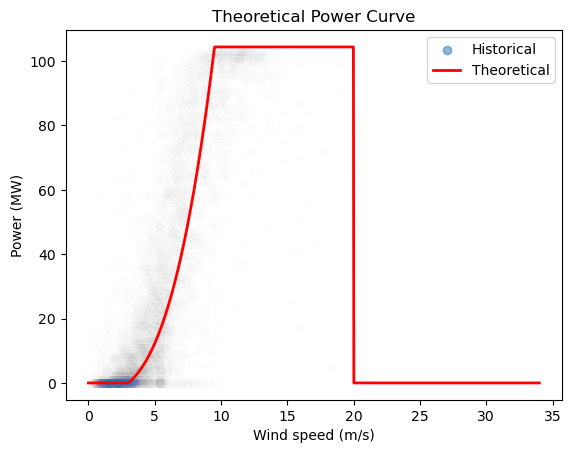

In [7]:
x = np.linspace(0, 34, 1000)
y = [power_curve(v) for v in x] # convert to MW

plt.scatter(df['speed'], df['power'], alpha=0.002, label='Historical')
plt.plot(x, y, label='Theoretical', color='red', linewidth=2)
plt.xlabel('Wind speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Theoretical Power Curve')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

## Pyron wake loss

In [8]:
np.set_printoptions(suppress=True, precision=6)

In [9]:
def PLF5(v, P, L, A, B, C):
    return L + (P - L) / (1 + (v / B) ** A) ** C

def PLF5_cut(v, P, L, A, B, C, cut_in=v_cut_in):
    base = L + (P - L) / (1 + (v / B) ** A) ** C
    return np.where(v < cut_in, 0, base)

In [10]:
# def power_curve_single(v):
#     if v < v_cut_in or v > v_cut_out:
#         return 0
#     else:
#         cut_in_val = (0.5 * rho * A * v_cut_in**3) * C_p / 1e6
#         power = (0.5 * rho * A * v**3) * C_p / 1e6 - cut_in_val
#         return min(power, 1.5)

def power_curve_single(v):
    if v < v_cut_in or v > v_cut_out:
        return 0
    else:
        cut_in_val = (0.5 * rho * A * v_cut_in**3) * C_p / 1e6
        power = (0.5 * rho * A * v**3) * C_p / 1e6 - cut_in_val
        return min(power, 1.8)

In [11]:
# coefficients of steady curve

# popt, pcov = curve_fit(
#     PLF5_cut,
#     df_train['speed'],
#     # df['power_cf'] * 1.5,
#     [power_curve_single(v) for v in df_train['speed']],
#     p0=[1.5, 0, -150, 10, 0.02],
#     bounds=([1.5, -100, -1000, 0, 0.01], np.inf),
#     maxfev=10000
# )

popt, pcov = curve_fit(
    PLF5_cut,
    df['speed'],
    df['pluswind'] * 1.8,
    p0=[1.8, 0, -150, 10, 0.02],
    maxfev=10000
)

In [12]:
popt

array([  1.78538 ,  -0.016297, -34.641357,   9.852624,   0.091661])

In [13]:
# find wake loss in each region
dens = np.array([18, 38, 41, 18, 65, 60, 42, 42]) * 1e6 / (18.5 * 300 * 11 * 300)
loss = pd.DataFrame({
    'ref': [0, 1, 2, 3, 4, 5, 6, 8, 10],
    'loss': [0, 1, 1.7, 2.3, 2.8, 3.2, 3.5, 3.8, 3.9]
})

poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(loss['ref'].values.reshape(-1, 1))

model = LinearRegression()
model.fit(X_poly, loss['loss'])

dens_poly = poly_features.fit_transform(dens.reshape(-1, 1))
y_pred = model.predict(dens_poly)
loss_density = np.round(y_pred / dens, 3)

In [75]:
# percent wind loss from wake loss

shape, loc, scale = weibull_min.fit(df['speed'])
def power_loss(v, C):
    return 163 * weibull_min.pdf(v, shape, loc=loc, scale=scale) * PLF5_cut(v * C, *popt)
def optimal_wind(C, val):
    return abs(quad(power_loss, 0.0001, 100, args=(C,))[0]) / abs((quad(power_loss, 0.0001, 100, args=(1,))[0] - val))
wind_losses = []
for loss in loss_density:
    result = minimize_scalar(optimal_wind, bounds=(0.7, 1), args=(loss,), method='bounded')
    wind_loss = np.round(result.x, 3)
    wind_losses.append(wind_loss)


# shape, loc, scale = weibull_min.fit(df['speed'])
# def power_loss(v, C):
#     return 58 * weibull_min.pdf(v, shape, loc=loc, scale=scale) * PLF5_cut(v * C, *popt)
# def optimal_wind(C, val):
#     return abs(quad(power_loss, 0.0001, 100, args=(C,))[0]) / abs((quad(power_loss, 0.0001, 100, args=(1,))[0] - val))
# wind_losses = []
# for loss in loss_density:
#     result = minimize_scalar(optimal_wind, bounds=(0.5, 1), args=(loss,), method='bounded')
#     wind_loss = np.round(result.x, 3)
#     wind_losses.append(wind_loss)

In [76]:
wind_losses

[0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7]

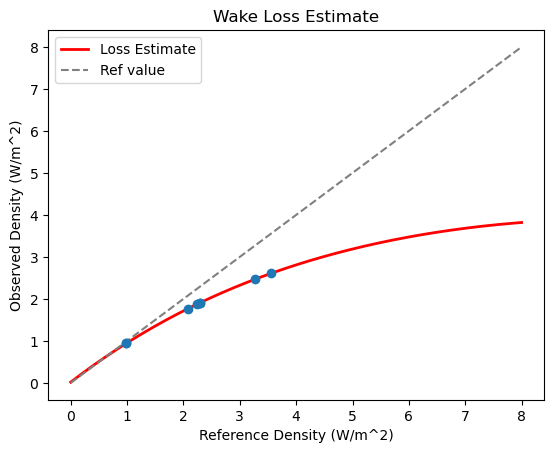

In [14]:
# curve for calculating wake loss
x = np.linspace(0, 8, num=1000)
y = model.predict(poly_features.fit_transform(x.reshape(-1, 1)))
plt.plot(x, y, label='Loss Estimate', color='red', linewidth=2)
plt.plot(x, x, label='Ref value', linestyle='--', color='gray')
plt.scatter(dens, y_pred, zorder=3)

plt.xlabel('Reference Density (W/m^2)')
plt.ylabel('Observed Density (W/m^2)')
plt.title('Wake Loss Estimate')
plt.legend()

##### calculate coefficients of wake loss curve

In [15]:
P_fixed = 1.8
L_fixed = -0.02119208
A_fixed = -159.94386670
B_fixed = 10.15037580
C_fixed = 0.01877349

weights = np.array([0.99 * 12, 25, 1, 12, 43, 16, 54])
wake_factors = np.array([0.976, 0.92, 0.913, 0.976, 0.86, 0.871, 0.91])

In [17]:
# 5 parameter logistic functions
def PLF5(v, P, L, A, B, C):
    return L + (P - L) / (1 + (v / B) ** A) ** C

def PLF5_cut(v, P, L, A, B, C, cut_in=v_cut_in):
    base = L + (P - L) / (1 + (v / B) ** A) ** C
    return np.where(v < cut_in, 0, base)

def total_wake_power(X):
    return sum(
        w * PLF5(X * f, P_fixed, L_fixed, A_fixed, B_fixed, C_fixed)
        for w, f in zip(weights, wake_factors)
    )

def fit_model(X, P, L, A, B, C):
    return PLF5_cut(X, P, L, A, B, C)

In [18]:
# X = np.linspace(0, 25, 1000)
# y = total_wake_power(X)
# popt, pcov = curve_fit(
#     fit_model,
#     X,
#     y,
#     p0=[244.5, -4, -40, 11.2, 0.07],
#     bounds=([244, -100, -1000, 8, 0.01], np.inf),
#     maxfev=10000
# )
# print(popt)


X = np.linspace(0, 22, 1000)
y = total_wake_power(X)
popt, pcov = curve_fit(
    fit_model,
    X,
    y,
    p0=[104.4, -4, -40, 11.2, 0.07],
    maxfev=10000
)
print(popt)

[293.253372  -3.598117 -40.142982  11.213254   0.074578]


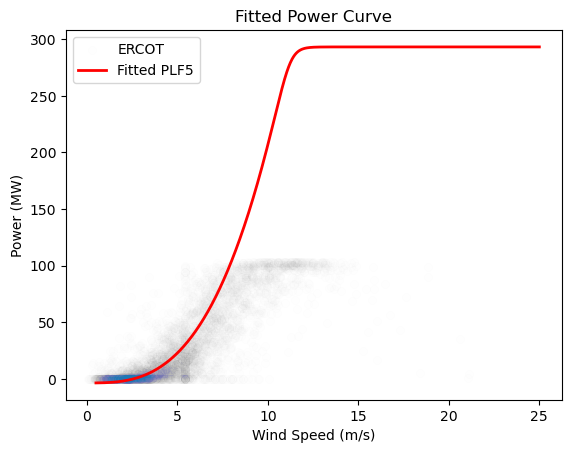

In [19]:
X = np.linspace(0.5, 25, 1000)
y = PLF5(X, *popt)

plt.scatter(df['speed'], df['power'], alpha=0.002, label='ERCOT')
plt.plot(X, y, label='Fitted PLF5', color='red', linewidth=2)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Fitted Power Curve')
plt.legend()

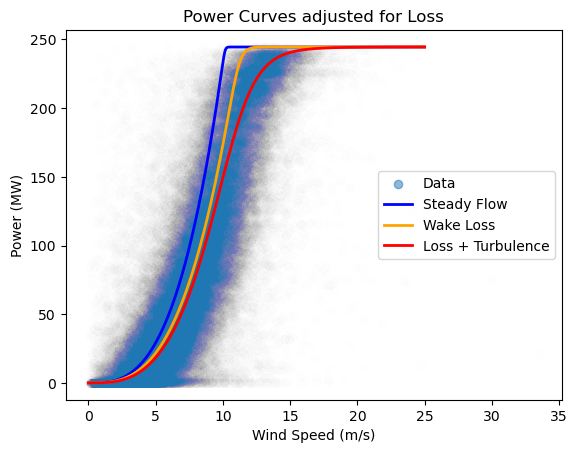

In [18]:
X = np.linspace(0, 25, 1000)
# y_st = 163 * PLF5(X, 1.5, -0.02181750, -161.50069891, 10.15104929, 0.01857233)
# y_wl = PLF5(X, 244.54466516, -3.57745000, -40.14553838, 11.21244215, 0.07457089)
# y_lt = PLF5(X, 244.4718239, -2.1593557, -10.9176942, 10.8237373, 0.2852041)

y_st = 163 * PLF5(X, 1.5, 0, -161.50069891, 10.15104929, 0.01857233)
y_wl = PLF5(X, 244.54466516, 0, -40.14553838, 11.21244215, 0.07457089)
# y_lt = PLF5(X, 244.4718239, 0, -10.9176942, 10.8237373, 0.2852041)
y_lt = PLF5(X, 244.5, 0, -10.7, 11.5, 0.29)

plt.scatter(df['speed'], df['power'], alpha=0.002, label='Data')
plt.plot(X, y_st, label='Steady Flow', linewidth=2, color='blue')
plt.plot(X, y_wl, label='Wake Loss', linewidth=2, color='orange')
plt.plot(X, y_lt, label='Loss + Turbulence', linewidth=2, color='red')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Power Curves adjusted for Loss')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)

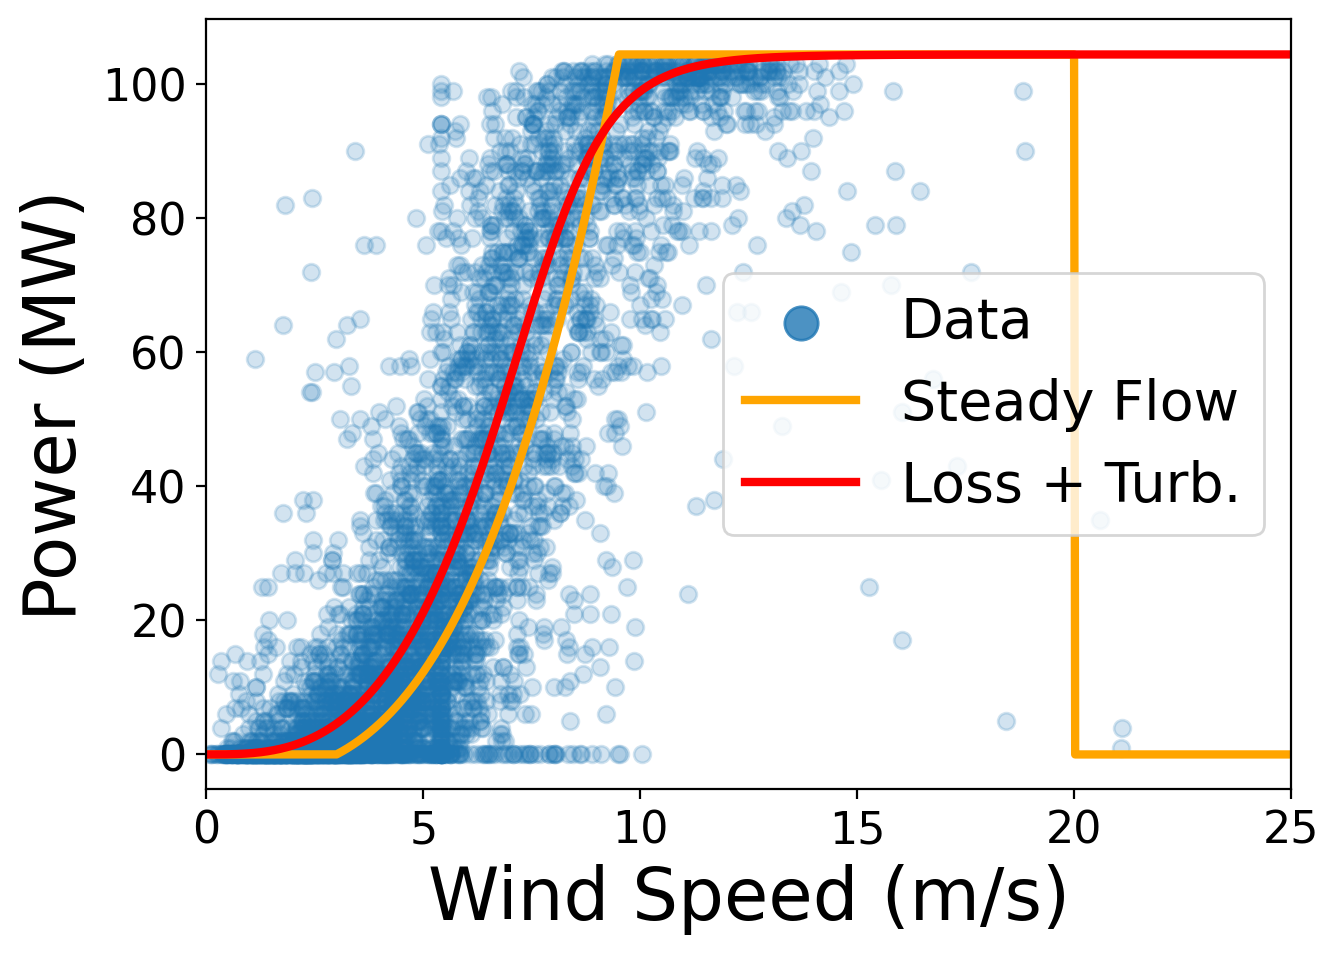

In [22]:
X = np.linspace(0, 25, 1000)
y = [power_curve(v) for v in X] # convert to MW
# y_lt = PLF5(X, 244.4718239, 0, -10.9176942, 10.8237373, 0.2852041)
# y_lt = PLF5(X, 244.5, 0, -10.7, 11.5, 0.29)
y_lt_eia = PLF5(X, 104.4, 0, -10, 8.5, 0.3)


alpha = 0.2

plt.figure(figsize=(7, 5), dpi=200)
plt.scatter(df['speed'], df['power'], alpha=alpha, label='Data')
plt.plot(X, y, label='Steady Flow', linewidth=3, color='orange')
plt.plot(X, y_lt_eia, label='Loss + Turb.', linewidth=3, color='red')
plt.xlabel('Wind Speed (m/s)', fontsize=26)
plt.xlim(0, 25)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Power (MW)', fontsize=26)
# plt.title('Power Curves Adjusted for Loss')

leg = plt.legend(fontsize=20, markerscale=2)
leg.legend_handles[0].set_alpha(0.8)

# Time Series

In [24]:
# params = (244.5, 0, -10.7, 11.5, 0.29)
params = (104.4, 0, -10, 8.5, 0.3)

df['power_lt'] = PLF5(df['speed'], *params)
# df_train['power_lt'] = PLF5(df_train['speed'], *params)
# df_test['power_lt'] = PLF5(df_test['speed'], *params)

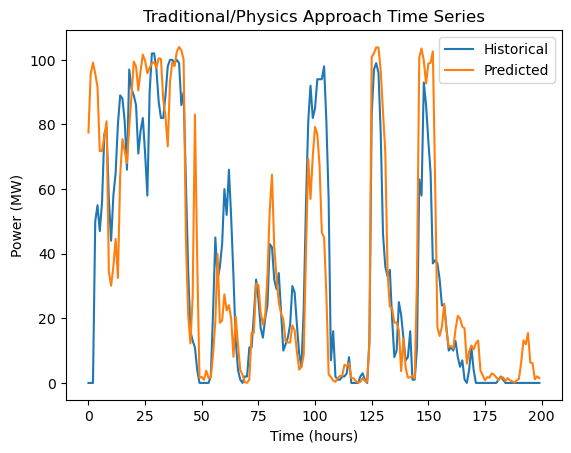

In [25]:
plt.plot(df['power'][:200], label='Historical')
plt.plot(df['power_lt'][:200], label='Predicted')

plt.title('Traditional/Physics Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

## with noise

In [26]:
from scipy.interpolate import make_splrep

In [37]:
# bin and fit std parameter to the historical power, as function of wind speed
def fit_std(speed, power, intervals, k=3, s=0):
    params = pd.DataFrame(columns=['avg_speed', 'std'])
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speed >= lower) & (speed < upper)]
        std = np.std(filtered_power)
        # print(std)
        params.loc[len(params)] = [avg_speed, std]
        # print(list(norm.fit(filtered_power, floc=0)))
        # params.loc[len(params)] = [avg_speed] + list(norm.fit(filtered_power, floc=10))

    std_spline = make_splrep(np.array(params['avg_speed']), np.array(params['std']), k=k, s=s)

    return std_spline

In [35]:
df['speed'].describe()

count    4411.000000
mean        5.397041
std         3.023065
min         0.085519
25%         3.056087
50%         5.034835
75%         7.171387
max        21.092634
Name: speed, dtype: float64

In [41]:
df[:3087]['power'].describe()

count    3087.000000
mean       28.561386
std        32.305603
min         0.000000
25%         1.000000
50%        14.000000
75%        50.000000
max       103.000000
Name: power, dtype: float64

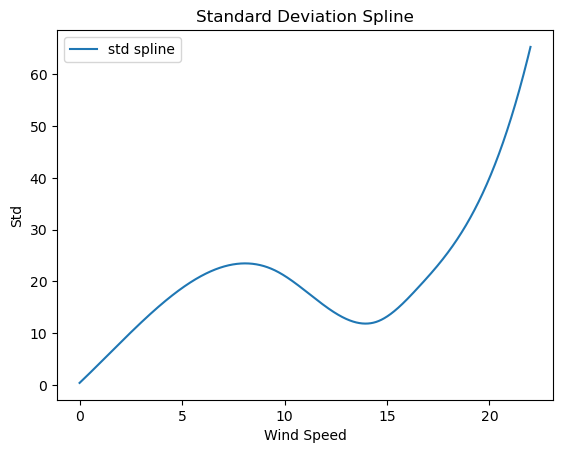

In [77]:
# intervals = np.append(np.arange(0, 21, 1), 34)
# x = np.linspace(0, 34, 10000)

# intervals = np.array([0, 0.3, 1])
# intervals = np.append(intervals, np.arange(2, 16, 1))
# intervals = np.append(intervals, 22)
intervals = np.append(np.arange(0, 19, 1), 22)
x = np.linspace(0, 22, 10000)

# std_spline = fit_std(df['speed'], df['power'], intervals, k=3, s=300)
# std_spline = fit_std(df_train['speed'], df_train['power'], intervals, k=3, s=300)
std_spline = fit_std(df['speed'], df['power'], intervals, k=3, s=300)

y = std_spline(x)
plt.plot(x, y, label='std spline')
# plt.scatter(intervals[:-1], [std_spline(i) for i in intervals[:-1]], marker='o', label='std_spline points')
plt.title('Standard Deviation Spline')
plt.xlabel('Wind Speed')
plt.ylabel('Std')
# plt.ylim(0, 60)
plt.legend()

In [78]:
intervals

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 22])

In [79]:
# normal noise
rated_power = 104.4

def apply_noise(speed, power, std_spline):
    noise = np.random.normal(0, std_spline(speed), size=1)[0]
    init_power = power + noise
    if init_power < 0 or init_power > rated_power:
        noise = -noise / 3
        if power+noise < 0 or power+noise > rated_power:
            noise = 0
    return power + noise


def apply_noise_brownian(speed, power, std_spline, size, smoothing=0.01, drift=0.001, start=None):
    start = np.random.uniform(low=0, high=1, size=1)[0] if start is None else start
    steps = np.random.normal(loc=0.01, scale=0.99, size=size)
    steps_smoothed = smoothing * steps
    walk = np.cumsum(steps_smoothed) + start

    for i in range(1, len(steps)):
        walk[i] = walk[i - 1] + steps_smoothed[i] + drift * (0.5 - walk[i - 1])
        # reflect walk if it goes out of bounds
        if walk[i] < 0:
            walk[i] = -walk[i]
        elif walk[i] > 1:
            walk[i] = 2 - walk[i]

    noise = norm.ppf(walk, loc=0, scale=std_spline(speed))
    init_power = power + noise

    new_power = [init_power[i] if init_power[i] >= 0 and init_power[i] <= rated_power
                 else (power[i] + noise[i]/3) for i in range(len(init_power))]
    new_power = np.array(new_power)
    new_power = np.clip(new_power, a_min=0, a_max=rated_power)
    return new_power

In [80]:
import sys
sys.path.append('../evaluation')
from evaluation import Metrics, Plot

In [83]:
# power_noise = df.apply(lambda row: apply_noise(row['speed'], row['power_lt'], std_spline), axis=1)
power_noise = apply_noise_brownian(df['speed'], df['power_lt'], std_spline, size=len(df), smoothing=0.01, drift=0.001)
# power_noise_train = apply_noise_brownian(df_train['speed'], df_train['power_lt'], std_spline, size=len(df_train), smoothing=0.01, drift=0.001)
# power_noise_test = apply_noise_brownian(df_test['speed'], df_test['power_lt'], std_spline, size=len(df_test), smoothing=0.01, drift=0.001)

df['preds'] = power_noise
# df_train['preds'] = power_noise_train
# df_test['preds'] = power_noise_test

trad_metrics = Metrics('Traditional', df['speed'], df['power'], df['preds'])
trad_metrics.print_metrics()

Traditional Metrics:
RMSE: 0.2115563134979202
Bias: 0.08396447655967401
Cross Correlation: 0.8364917010044649
Similarity: 0.5406079346861623
RMS Steady: 97.3616047970599
RMS Loss: 80.80075426915528
RMS True: 46.85261987464643
RMS Predicted: 54.31976298731198


In [86]:
df['npreds'] = df['preds'] / df['preds'].max()

In [88]:
# df.to_csv('new_trained_results/trad_1423.csv', index=False)
df.to_csv('new_trained_results/wevalidate/trad_eia.csv', index=False)

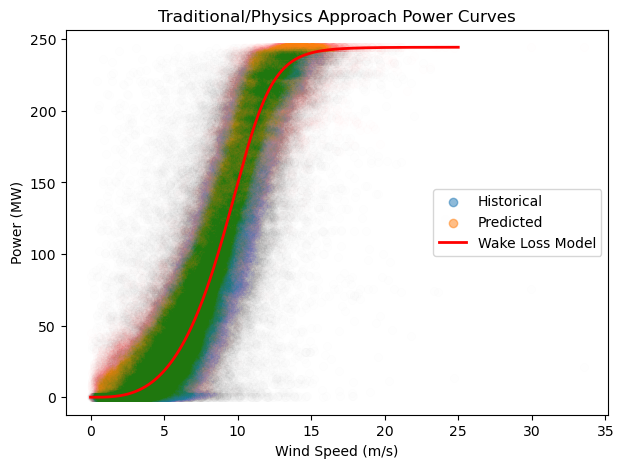

In [95]:
plt.figure(figsize=(7, 5))
plt.scatter(df['speed'], df['power'], alpha=0.002, label='Historical')
plt.scatter(df['speed'], power_noise, alpha=0.002, label='Predicted')

x = np.linspace(0, 25, 1000)
plt.plot(x, y_lt, color='red', label='Wake Loss Model', linewidth=2)

plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (MW)')
plt.title('Traditional/Physics Approach Power Curves')

leg = plt.legend()
leg.legend_handles[0].set_alpha(0.5)
leg.legend_handles[1].set_alpha(0.5)

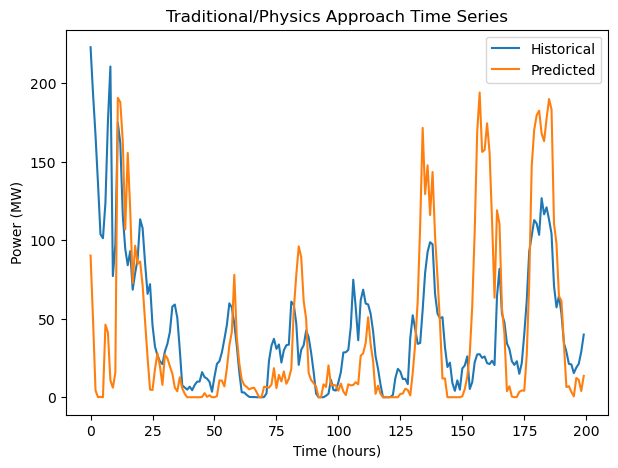

In [91]:
plt.figure(figsize=(7, 5))
plt.plot(df['power'][:200], label='Historical')
plt.plot(power_noise[:200], label='Predicted')
plt.title('Traditional/Physics Approach Time Series')
plt.xlabel('Time (hours)')
plt.ylabel('Power (MW)')
plt.legend()

### comparing power curves

In [39]:
import sys
sys.path.append('../evaluation')
from evaluation import Metrics, Plot

Traditional Metrics:
RMSE: 0.208007215317947
Bias: 0.034715616628725125
Cross Correlation: 0.786760728098035
Similarity: 0.7308684727334067
RMS Steady: 152.4913645788543
RMS Loss: 130.40171541325668
RMS True: 115.71622192601852
RMS Predicted: 124.93220275862751


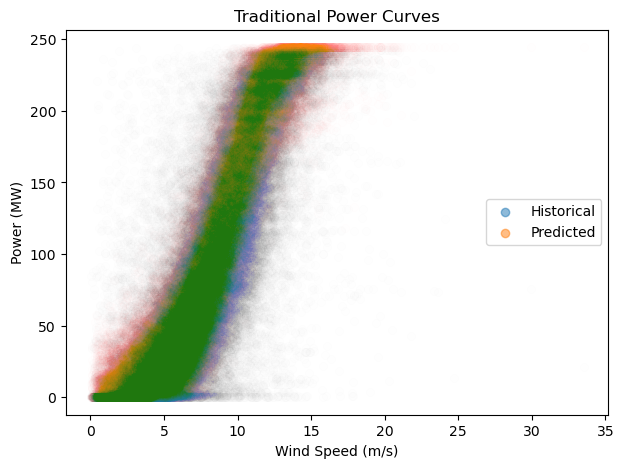

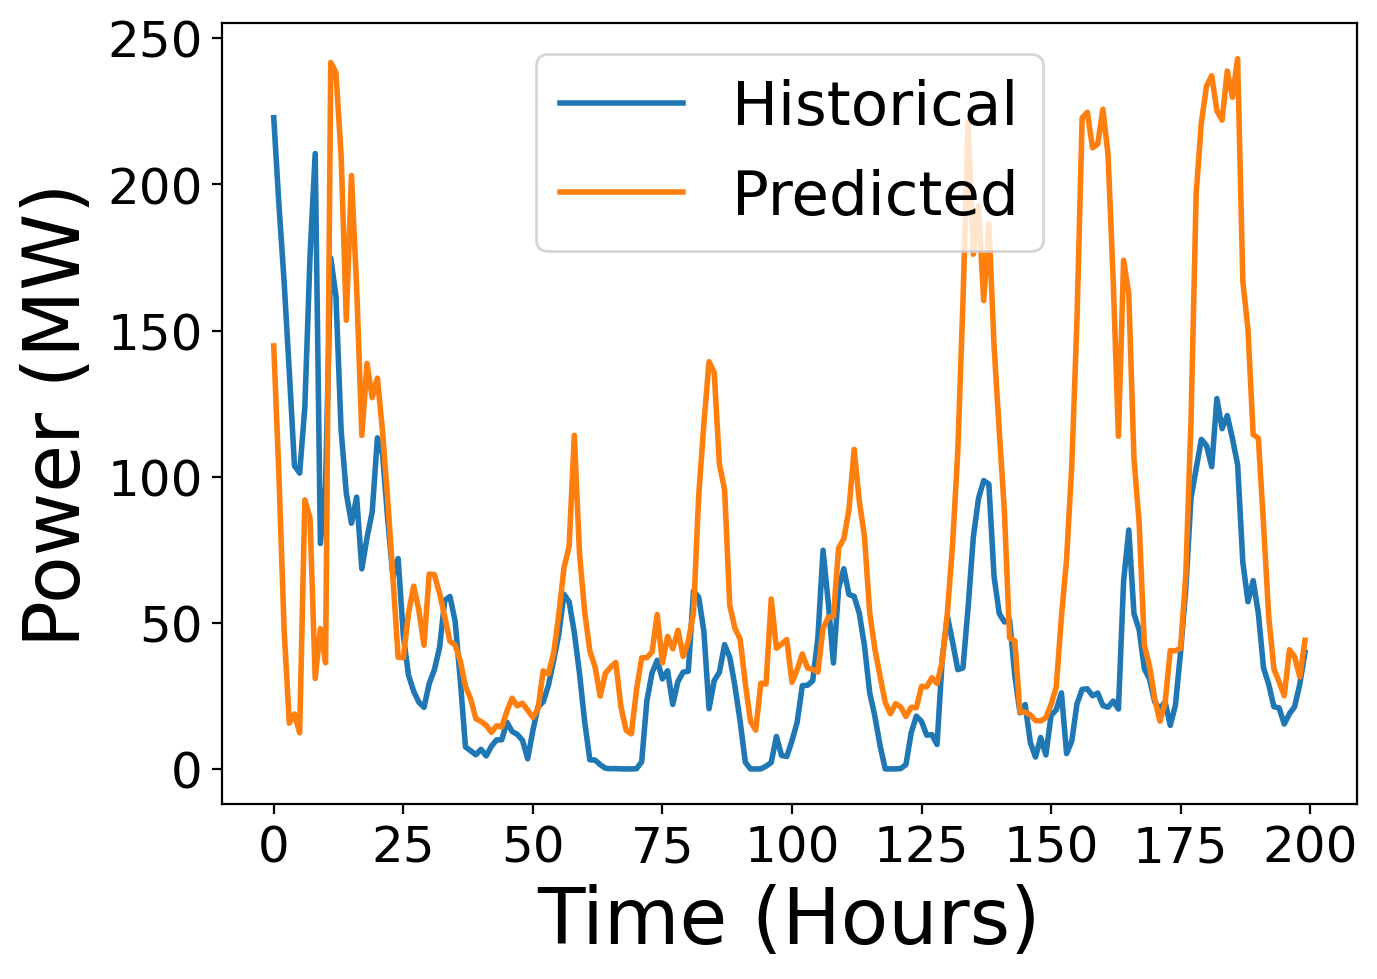

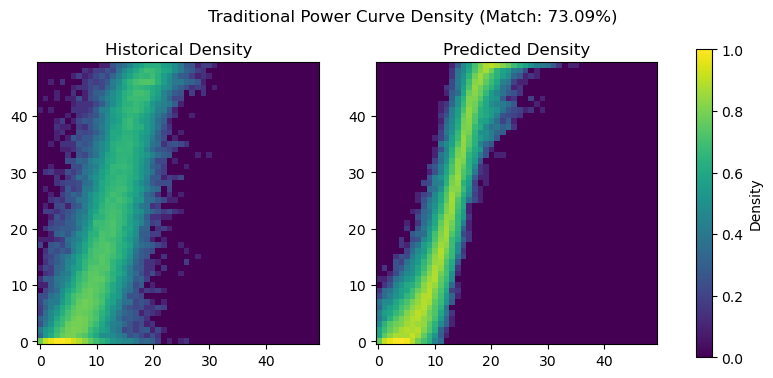

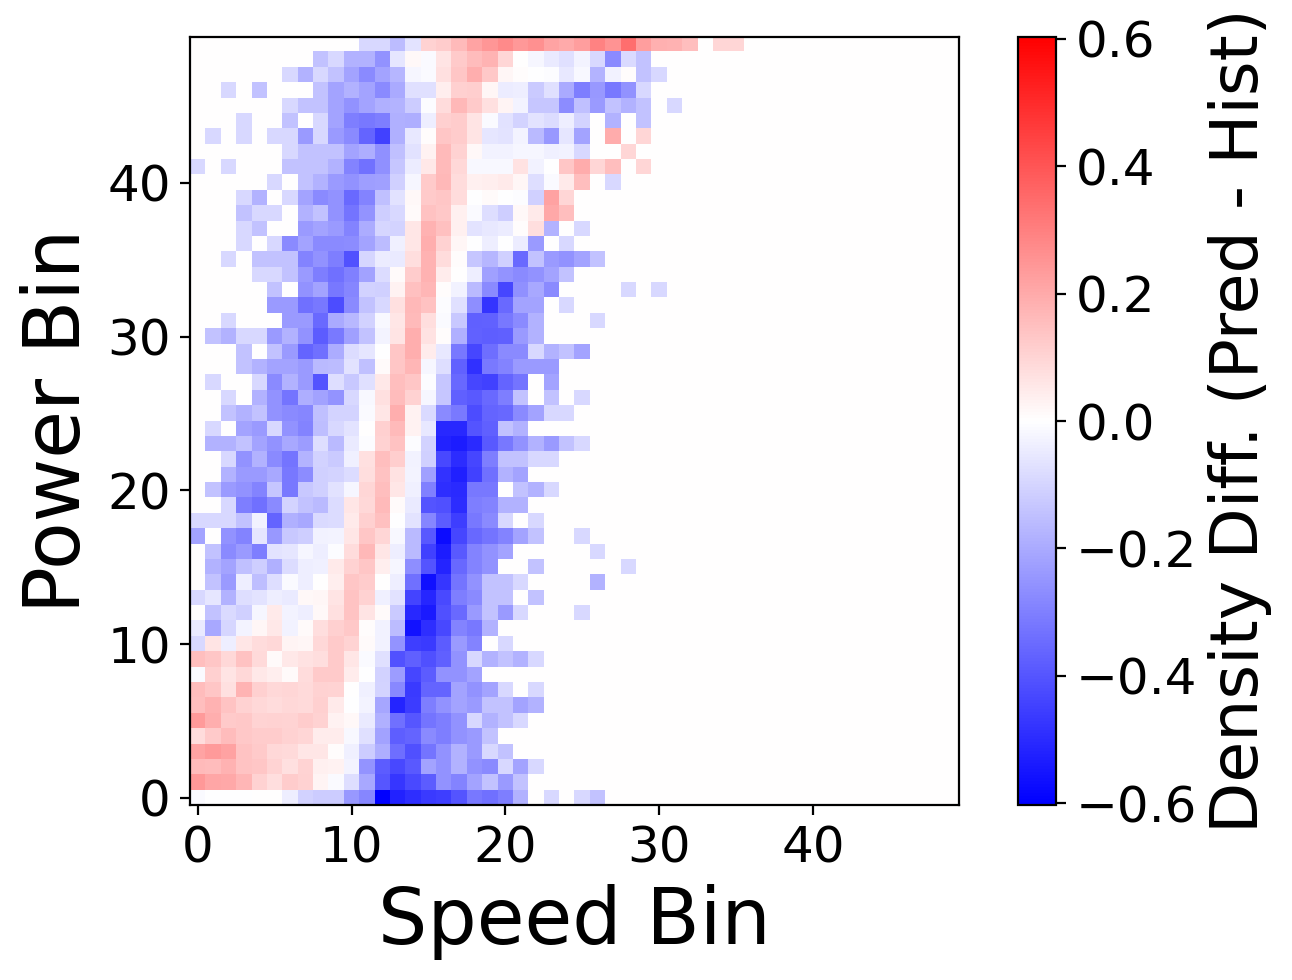

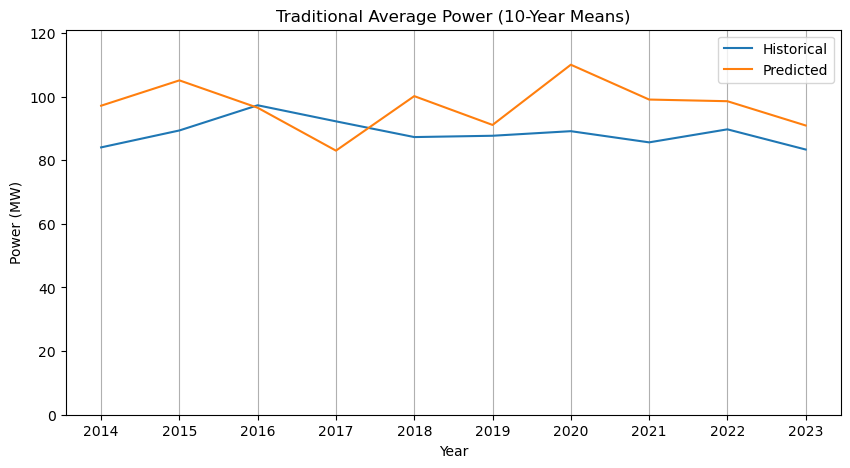

In [100]:
trad_metrics = Metrics('Traditional', df['speed'], df['power'], df['preds'])
trad_plot = Plot('Traditional', df['speed'], df['power'], df['preds'])
trad_metrics.print_metrics()
trad_plot.plot_all()

# trad_metrics = Metrics('Traditional', df_test['speed'], df_test['power'], df_test['preds'])
# trad_plot = Plot('Traditional', df_test['speed'], df_test['power'], df_test['preds'])
# trad_metrics.print_metrics()
# trad_plot.plot_all()

In [214]:
df.to_csv('new_results/trad_1423_brownian.csv', index=False)

In [179]:
from scipy.spatial.distance import jensenshannon

In [180]:
H_true, _, _ = np.histogram2d(df['speed'], df['power'], bins=50)
H_pred, _, _ = np.histogram2d(df['speed'], power_noise, bins=50)

# normalize
H_true_norm = H_true / H_true.sum()
H_pred_norm = H_pred / H_pred.sum()

mse = np.mean((H_true_norm - H_pred_norm) ** 2)
js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())  # Value between 0 and 1
similarity = 1 - js_div
match_percentage = np.round(similarity * 100, 2)

In [181]:
print(f"MSE: {mse}")
print(f"JS Divergence: {js_div}")
print(f"Similarity: {similarity}")
print(f"Match Percentage: {match_percentage}%")

MSE: 2.8699860776668355e-07
JS Divergence: 0.22603171990209353
Similarity: 0.7739682800979064
Match Percentage: 77.4%


Text(0.5, 0.98, 'Trad/Physics Power Curves (Match: 60.68%)')

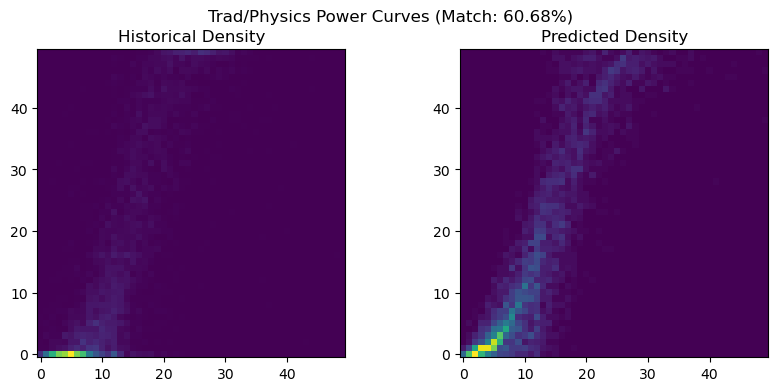

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(H_true_norm.T, origin='lower')
axs[0].set_title("Historical Density")

axs[1].imshow(H_pred_norm.T, origin='lower')
axs[1].set_title("Predicted Density")

fig.suptitle(f"Trad/Physics Power Curves (Match: {match_percentage}%)")

Text(0.5, 1.0, 'Historical Power Curve')

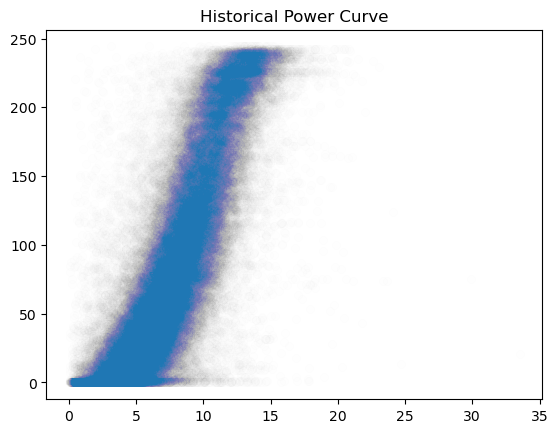

In [61]:
plt.scatter(df['speed'], df['power'], alpha=0.002)
plt.title('Historical Power Curve')

## save csv for we-validate

In [98]:
from datetime import datetime, timedelta

In [99]:
df['preds'] = power_noise
df['npreds'] = df['preds'] / 244.5

In [101]:
df.rename(columns={'datetime': 'time_stamp'}, inplace=True)

In [102]:
df

,time_stamp,power,npower,speed,pluswind,power_lt,preds,npreds
0,2018-07-01 05:00:00,0,0.000000,8.061592,0.520461,77.513923,3.598997,0.014720
1,2018-07-01 06:00:00,0,0.000000,9.478211,0.860001,95.700522,84.523151,0.345698
2,2018-07-01 07:00:00,0,0.000000,10.042563,0.952192,99.124307,96.534595,0.394825
3,2018-07-01 08:00:00,50,0.485437,9.480452,0.860676,95.717593,94.771520,0.387614
4,2018-07-01 09:00:00,55,0.533981,9.033495,0.737710,91.643763,86.655028,0.354417
...,...,...,...,...,...,...,...,...
4406,2018-12-31 19:00:00,7,0.067961,4.305253,0.068010,13.561100,21.143260,0.086476
4407,2018-12-31 20:00:00,1,0.009709,2.721040,0.000000,3.424894,7.900082,0.032311
4408,2018-12-31 21:00:00,2,0.019417,2.019171,0.000000,1.399468,3.980397,0.016280
4409,2018-12-31 22:00:00,0,0.000000,1.126299,0.000000,0.242887,1.865024,0.007628


In [67]:
# generate time_stamps in order for we-validate compatibility
def generate_time_stamps(start_date):
    current = start_date
    time_stamps = []
    # while len(time_stamps) < 34856:
    while len(time_stamps) < 82300:
        time_stamps.append(current.strftime('%Y-%m-%d %H:%M:%S'))
        current += timedelta(hours=1)
    return time_stamps

# time_stamp = generate_time_stamps(datetime(2018, 1, 1, 1, 0, 0))
time_stamp = generate_time_stamps(datetime(2014, 7, 30, 12, 0, 0))
df['time_stamp'] = time_stamp

In [68]:
df

,time_stamp,speed,power,npower,nspeed,power_lt,preds,npreds
0,2014-07-30 12:00:00,9.416307,222.814,0.912316,0.280607,149.752828,137.755872,0.563419
1,2014-07-30 13:00:00,8.168459,193.077,0.790557,0.243382,100.462967,87.264975,0.356912
2,2014-07-30 14:00:00,6.081183,166.707,0.682585,0.181116,40.583149,54.894012,0.224515
3,2014-07-30 15:00:00,3.644644,135.965,0.556711,0.108431,8.246686,38.411378,0.157102
4,2014-07-30 16:00:00,4.062179,103.724,0.424700,0.120886,11.559749,21.868490,0.089442
...,...,...,...,...,...,...,...,...
82295,2023-12-19 11:00:00,10.002887,14.636,0.059927,0.298106,172.944339,184.907096,0.756266
82296,2023-12-19 12:00:00,9.850973,5.243,0.021468,0.293574,167.112013,137.147763,0.560932
82297,2023-12-19 13:00:00,9.078698,0.446,0.001826,0.270536,135.996258,173.734671,0.710571
82298,2023-12-19 14:00:00,8.771991,0.195,0.000798,0.261387,123.626537,171.832568,0.702792


In [104]:
df.to_csv('wevalidate_data/EIA_930_trad.csv', index=False)